# Python Basics Practice Notebook (BTC & ETH)

You can run this notebook in **Google Colab** or Jupyter Notebook.  
Please **read each instruction carefully** and complete the code cells step by step.

---

## Learning Goals

By working through this notebook, you will:

- Use Python as a **calculator** and work with **basic data types** (`int`, `float`, `str`, `bool`).
- Inspect and **modify data types** in real datasets.
- Create and manipulate **lists** and **dictionaries**.
- Write simple **functions**.
- Use **NumPy** to work with numerical arrays.
- Use **Pandas** to load and explore CSV files.
- Use **Matplotlib** to create basic charts (line, bar, pie, scatter) for cryptocurrency data.

All the cryptocurrency-related examples in this notebook are based on **two CSV tables**:

- `bitcoin_daily.csv`
- `ethereum_daily.csv`


## Data Dictionary: Cryptocurrency Daily Data (BTC & ETH)

This notebook uses two datasets:

- `bitcoin_daily.csv` – Daily market data for **Bitcoin (BTC)**
- `ethereum_daily.csv` – Daily market data for **Ethereum (ETH)**

Each row in the dataset represents **one trading day** for the cryptocurrency.

---

### Column Descriptions

| Column Name        | Data Type               | Description |
|--------------------|-------------------------|-------------|
| `date`             | `str` / `datetime`      | The calendar date of the observation in `YYYY-MM-DD` format. |
| `price_usd`        | `float`                 | The closing price of the cryptocurrency on that day, measured in **US dollars (USD)**. |
| `market_cap_usd`   | `float`                 | Market capitalization in USD, calculated as **price × circulating supply**. It represents the total market value of the cryptocurrency. |
| `volume_usd`       | `float`                 | Daily trading volume in USD, showing how much of the cryptocurrency was traded during that day. |

---

### Notes for Students

- **Price (`price_usd`)** shows how much one unit of BTC or ETH is worth.
- **Market capitalization (`market_cap_usd`)** reflects the overall size of the cryptocurrency market.
- **Trading volume (`volume_usd`)** indicates market activity and liquidity.
- When loading data from a CSV file, the `date` column is usually read as a **string** and can be converted to a `datetime` type for time-series analysis.

---

### Example Interpretation (One Row)

If on a given date:
- `price_usd` = 42,000  
- `market_cap_usd` = 820,000,000,000  
- `volume_usd` = 28,000,000,000  

This means:
- One unit of the cryptocurrency costs **USD 42,000**
- The total market value is **USD 820 billion**
- **USD 28 billion** worth of the cryptocurrency was traded on that day


---
## Part 0 – Setup and Load Data

In this part, we:

1. Import the Python libraries we will use.
2. Configure Matplotlib so that charts show nicely inside the notebook.
3. **Load the BTC and ETH daily CSV tables** using `pd.read_csv`.

### Instructions

1. Make sure the two CSV files are in the same folder as this notebook (or in your Colab working directory).
2. Run the code cell below **once**.
3. If you see the shapes of the two tables printed without errors, the setup is successful.


In [1]:
# Part 0 – Setup: import commonly used libraries and load CSV data

import math              # For some basic math functions (optional)
import numpy as np       # For numerical calculations
import pandas as pd      # For working with tables / CSV files
import matplotlib.pyplot as plt  # For making charts

**task 0: load the two CSV tables**

In [2]:
# Load the two CSV tables for Bitcoin and Ethereum
btc_df = pd.read_csv("bitcoin_daily.csv")
eth_df = pd.read_csv("ethereum_daily.csv")


In [3]:
print("Bitcoin DataFrame shape:", btc_df.shape)
print("Ethereum DataFrame shape:", eth_df.shape)

print("\nSetup complete! Libraries imported and CSV tables loaded successfully.")

Bitcoin DataFrame shape: (366, 8)
Ethereum DataFrame shape: (366, 8)

Setup complete! Libraries imported and CSV tables loaded successfully.


---
## Part 1 – Python Data Types

We will look at the **data types** (dtypes) inside our real BTC/ETH tables and practice:

- Checking the current dtypes.
- Converting columns to the correct type.
- Validating the data types of individual values.


### Part 1.1 – Inspect and Modify Data Types in the BTC & ETH Tables

Now we work with **real data types** from the BTC and ETH tables.

We will:

1. Print the `dtypes` of both DataFrames.
2. Convert the `date` column from object to **datetime**.
3. Convert `day_start_ts_s` from float to **integer** (seconds since epoch).
4. Check the Python types of some individual values, for example:
   - One BTC closing price
   - One ETH market cap


In [4]:
# Inspect and modify dtypes

print("=== Original dtypes for Bitcoin ===")
print(btc_df.dtypes)

print("\n=== Original dtypes for Ethereum ===")
print(eth_df.dtypes)

=== Original dtypes for Bitcoin ===
date                        str
day_start_ts_s          float64
price_open_usd          float64
price_high_usd          float64
price_low_usd           float64
price_close_usd         float64
market_cap_close_usd    float64
volume_24h_close_usd    float64
dtype: object

=== Original dtypes for Ethereum ===
date                        str
day_start_ts_s          float64
price_open_usd          float64
price_high_usd          float64
price_low_usd           float64
price_close_usd         float64
market_cap_close_usd    float64
volume_24h_close_usd    float64
dtype: object


**task 1.1.1: Convert the `date` column from object to `datetime`**

In [5]:
# 1) Convert 'date' column to datetime
btc_df["date"] = pd.to_datetime(btc_df["date"])
eth_df["date"] = pd.to_datetime(eth_df["date"])


**task 1.1.2: Convert `day_start_ts_s` from float to `integer`**

In [6]:
# 2) Convert 'day_start_ts_s' from float to int
btc_df["day_start_ts_s"] = btc_df["day_start_ts_s"].astype(int)
eth_df["day_start_ts_s"] = eth_df["day_start_ts_s"].astype(int)


In [7]:
print("\n=== dtypes AFTER conversion ===")
print("Bitcoin dtypes:")
print(btc_df.dtypes)

print("\nEthereum dtypes:")
print(eth_df.dtypes)



=== dtypes AFTER conversion ===
Bitcoin dtypes:
date                    datetime64[us]
day_start_ts_s                   int64
price_open_usd                 float64
price_high_usd                 float64
price_low_usd                  float64
price_close_usd                float64
market_cap_close_usd           float64
volume_24h_close_usd           float64
dtype: object

Ethereum dtypes:
date                    datetime64[us]
day_start_ts_s                   int64
price_open_usd                 float64
price_high_usd                 float64
price_low_usd                  float64
price_close_usd                float64
market_cap_close_usd           float64
volume_24h_close_usd           float64
dtype: object


In [8]:
# 3) Check the Python types of some individual values
example_btc_close = btc_df["price_close_usd"].iloc[0]
example_eth_mktcap = eth_df["market_cap_close_usd"].iloc[0]

print("\nExample BTC close price value:", example_btc_close, "| Python type:", type(example_btc_close))
print("Example ETH market cap value:", example_eth_mktcap, "| Python type:", type(example_eth_mktcap))



Example BTC close price value: 96732.3889915353 | Python type: <class 'numpy.float64'>
Example ETH market cap value: 389948669986.36505 | Python type: <class 'numpy.float64'>


### Part 1.2 – A Simple Investment Calculation Using BTC Prices

Now we use the **actual BTC daily data**.

1. Take the **first day’s closing price** from `btc_df`.
2. Suppose you invest **100 USD** in BTC at that closing price.
3. Calculate how many BTC you could buy, and what the value would be if the price changes to the **last day’s closing price**.

In [9]:
# Using real BTC closing prices from the CSV table

# Take the first and last closing prices from the BTC DataFrame
first_close_btc = btc_df["price_close_usd"].iloc[0]
last_close_btc = btc_df["price_close_usd"].iloc[-1]

print("First day close price (BTC):", first_close_btc)
print("Last day close price (BTC):", last_close_btc)


First day close price (BTC): 96732.3889915353
Last day close price (BTC): 94872.54700005168


**task 1.2: Calculate how many BTC you could buy, and what the value would be if the price changes to the `last day’s closing price`**

In [10]:
# Suppose we invest 100 USD at the first closing price
initial_investment_usd = 100.0

# How many BTC can we buy?
btc_bought = initial_investment_usd / first_close_btc

# What is the value of these BTC at the last closing price?
final_value_usd = btc_bought * last_close_btc

print("\nWith", initial_investment_usd, "USD, you could buy", btc_bought, "BTC.")
print("If the price later becomes", last_close_btc, "USD,")
print("your investment would be worth", final_value_usd, "USD.")



With 100.0 USD, you could buy 0.0010337799060121488 BTC.
If the price later becomes 94872.54700005168 USD,
your investment would be worth 98.0773327208466 USD.


---
## Part 2 – Lists

A **list** is an ordered collection of items. Lists are very common in Python and data analysis.

In this section, we create lists using **real BTC daily closing prices**.


In [11]:
# Create a list of the first 5 daily closing prices for BTC
btc_close_list = list(btc_df["price_close_usd"].head(5))

print("btc_close_list:", btc_close_list)
print("Type of btc_close_list:", type(btc_close_list))


btc_close_list: [96732.3889915353, 99725.40578888806, 99877.5171161229, 104347.54717350486, 104216.89840135272]
Type of btc_close_list: <class 'list'>


**task 2.1 – Basic list operations**

In [12]:
# Access items by index (indices start at 0)
first_price = btc_close_list[0]
second_price = btc_close_list[1]
fifth_price = btc_close_list[4]

print("First price:", first_price)
print("Second price:", second_price)
print("Fifth price:", fifth_price)

# Length of the list
print("Number of prices in the list:", len(btc_close_list))


First price: 96732.3889915353
Second price: 99725.40578888806
Fifth price: 104216.89840135272
Number of prices in the list: 5


**task 2.2 – Modifying a list**

In [13]:
print("Original list:", btc_close_list)

# Append a new price (for practice, use the last known price * 1.02)
btc_close_list.append(btc_close_list[-1] * 1.02)
print("After appending a new (hypothetical) price:", btc_close_list)

# Change the first price (pretend we discovered a small error)
btc_close_list[0] = btc_close_list[0] * 0.99
print("After adjusting the first price:", btc_close_list)


Original list: [96732.3889915353, 99725.40578888806, 99877.5171161229, 104347.54717350486, 104216.89840135272]
After appending a new (hypothetical) price: [96732.3889915353, 99725.40578888806, 99877.5171161229, 104347.54717350486, 104216.89840135272, 106301.23636937978]
After adjusting the first price: [95765.06510161996, 99725.40578888806, 99877.5171161229, 104347.54717350486, 104216.89840135272, 106301.23636937978]


**task 2.3 – List slicing**

In [14]:
# Take the first three prices
first_three = btc_close_list[0:3]
print("First three prices:", first_three)


First three prices: [95765.06510161996, 99725.40578888806, 99877.5171161229]


---
## Part 3 – Dictionaries

Now we create a dictionary that maps a coin symbol to its **latest closing price** based on the BTC and ETH tables.


In [15]:
# Create and use a dictionary based on the CSV data

# Latest (last row) closing price for each coin
latest_btc_price = float(btc_df["price_close_usd"].iloc[-1])
latest_eth_price = float(eth_df["price_close_usd"].iloc[-1])

# Create a dictionary mapping coin symbol to its latest close price
crypto_prices = {
    "BTC": latest_btc_price,
    "ETH": latest_eth_price,
}


**task 3.1: access values by key**

In [16]:
print("Latest BTC price:", crypto_prices["BTC"])
print("Latest ETH price:", crypto_prices["ETH"])

Latest BTC price: 94872.54700005168
Latest ETH price: 3327.2722963292276


**task 3.2 – Adding and updating dictionary entries**

In [17]:
# Add a new practice entry (e.g., a made-up coin)
crypto_prices["EXAMPLE"] = 1.23
print("After adding EXAMPLE:", crypto_prices)

# Update BTC price (for practice, assume a 1% increase)
crypto_prices["BTC"] = crypto_prices["BTC"] * 1.01
print("After updating BTC price (simulated +1%):", crypto_prices)

# Get all keys and values
print("All coin symbols:", list(crypto_prices.keys()))
print("All prices:", list(crypto_prices.values()))


After adding EXAMPLE: {'BTC': 94872.54700005168, 'ETH': 3327.2722963292276, 'EXAMPLE': 1.23}
After updating BTC price (simulated +1%): {'BTC': 95821.2724700522, 'ETH': 3327.2722963292276, 'EXAMPLE': 1.23}
All coin symbols: ['BTC', 'ETH', 'EXAMPLE']
All prices: [95821.2724700522, 3327.2722963292276, 1.23]


---
## Part 4 – Loops and Simple Conditions

We now loop through `crypto_prices` and classify each coin as “cheap” or “expensive”
based on a simple rule:

- If the latest closing price < 10,000 USD → "cheap"
- Otherwise → "expensive"


**task 4.1 – Loop with a simple condition**

In [18]:
for symbol, price in crypto_prices.items():
    if price < 10000:
        category = "cheap"
    else:
        category = "expensive"
    print(symbol, "has latest closing price", price, "=>", category)


BTC has latest closing price 95821.2724700522 => expensive
ETH has latest closing price 3327.2722963292276 => cheap
EXAMPLE has latest closing price 1.23 => cheap


---
## Part 5 – Functions

We will define small helper functions and then reuse them.


**task 5.1 – Define and use a simple function**

In [19]:
def usd_to_hkd(amount_usd, rate=7.8):
    """Convert an amount in USD to HKD using the given exchange rate."""
    hkd_value = amount_usd * rate
    return hkd_value

# Test the function
example_usd = 100
example_hkd = usd_to_hkd(example_usd)
print(example_usd, "USD is approximately", example_hkd, "HKD.")

100 USD is approximately 780.0 HKD.


**task 5.2 – Compute the average of a list manually**

In [20]:
def average_list(numbers):
    """Return the average (mean) of a list of numbers."""
    total = 0
    count = 0
    for value in numbers:
        total += value
        count += 1
    if count == 0:
        return None  # avoid division by zero
    return total / count

# Test the function with our BTC close price list
avg_btc_close = average_list(btc_close_list)
print("BTC close price list:", btc_close_list)
print("Average of these BTC close prices:", avg_btc_close)


BTC close price list: [95765.06510161996, 99725.40578888806, 99877.5171161229, 104347.54717350486, 104216.89840135272, 106301.23636937978]
Average of these BTC close prices: 101705.61165847804


---
## Part 6 – NumPy Basics

Now we use **NumPy arrays** to work with the full series of BTC closing prices.


**task 6.1 – Create a NumPy array from the BTC 'price_close_usd' column**

In [21]:
btc_close_array = np.array(btc_df["price_close_usd"])

print("btc_close_array:", btc_close_array)
print("Type:", type(btc_close_array))

print("Mean BTC close price:", np.mean(btc_close_array))
print("Max BTC close price:", np.max(btc_close_array))
print("Min BTC close price:", np.min(btc_close_array))

btc_close_array: [ 96732.38899154  99725.40578889  99877.51711612 104347.5471735
 104216.89840135 103221.86907925 103446.73844314 106011.7355199
 103889.57174881 103996.38358574 104828.41023434 105043.52337872
 104252.44945478 101728.82790774 101191.8542201  103505.30962657
 105121.06862147 102231.12837695 100522.89746095  97815.84535257
 101786.57409375  97690.61739242  96439.88149814  96928.85157608
  96108.29568063  96487.05436254  95841.18012309  97390.44349743
  95561.70494164  97917.74883921  96374.20669517  97190.84281504
  97545.41608103  96889.88885007  95910.63439975  95259.61791982
  96540.84301901  98227.33206793  95744.67131189  96635.74766481
  96100.14512744  92361.39840402  89006.72620144  84301.81196812
  84575.08070077  84116.90940478  86064.66466956  94770.10370202
  86170.71147755  87536.70299446  90503.36669782  90450.75262239
  86744.2444544   86295.78124249  80182.87188782  79505.93316264
  83157.48605838  83667.40552069  81318.8521901   84346.89648742
  84358.91

**task 6.2 – convert `btc_close_array`(BTC closing prices) into HKD**

In [22]:
exchange_rate = 7.8  # 1 USD ≈ 7.8 HKD (example)

btc_close_hkd = btc_close_array * exchange_rate

print("BTC prices in USD:", btc_close_array[:5], "...")
print("BTC prices in HKD:", btc_close_hkd[:5], "...")


BTC prices in USD: [ 96732.38899154  99725.40578889  99877.51711612 104347.5471735
 104216.89840135] ...
BTC prices in HKD: [754512.63413398 777858.16515333 779044.63350576 813910.86795334
 812891.80753055] ...


---
## Part 7 – Pandas and Basic Table Exploration

We already loaded the BTC and ETH CSV files into `btc_df` and `eth_df`.

Now we will practice **inspecting** these tables using simple Pandas operations.


**task 7.1 – Inspect basic information for each table**

In [23]:
print("=== Bitcoin – first 10 rows ===")
print(btc_df.head(10))
print("Columns:", list(btc_df.columns))

print("\n=== Ethereum – first 10 rows ===")
print(eth_df.head(10))
print("Columns:", list(eth_df.columns))


=== Bitcoin – first 10 rows ===
        date  day_start_ts_s  price_open_usd  price_high_usd  price_low_usd  \
0 2025-01-14      1736812800    94504.268495    97094.580715   94451.912722   
1 2025-01-15      1736899200    96535.260054    99895.530960   96535.260054   
2 2025-01-16      1736985600   100554.749105   100554.749105   97532.253460   
3 2025-01-17      1737072000    99977.504388   105850.050417   99977.504388   
4 2025-01-18      1737158400   104125.163503   104838.548282  102721.618833   
5 2025-01-19      1737244800   104451.817056   106085.440558  103221.869079   
6 2025-01-20      1737331200   101275.337148   108228.267625   99717.609750   
7 2025-01-21      1737417600   102094.728839   106969.681008  101063.539646   
8 2025-01-22      1737504000   106193.341794   106194.217801  103809.425980   
9 2025-01-23      1737590400   103610.288472   105928.726268  101524.957807   

   price_close_usd  market_cap_close_usd  volume_24h_close_usd  
0     96732.388992          1.916

**task 7.2 – Basic summary statistics for key numeric columns (use describe())**

In [24]:
btc_numeric_cols = ["price_open_usd", "price_high_usd", "price_low_usd", "price_close_usd",
                    "market_cap_close_usd", "volume_24h_close_usd"]
eth_numeric_cols = btc_numeric_cols  # same column names

print("=== Bitcoin – summary statistics ===")
print(btc_df[btc_numeric_cols].describe())

print("\n=== Ethereum – summary statistics ===")
print(eth_df[eth_numeric_cols].describe())


=== Bitcoin – summary statistics ===
       price_open_usd  price_high_usd  price_low_usd  price_close_usd  \
count      366.000000      366.000000     366.000000       366.000000   
mean    101444.767127   102732.153072  100113.072070    101477.770714   
std      11845.178274    11766.148424   11950.574365     11849.654811   
min      76300.778438    79898.184736   74773.258793     76617.757501   
25%      90656.122528    92029.332405   89481.830705     90514.083445   
50%     103539.867940   104863.884553  101726.754247    103529.622345   
75%     110936.363635   112296.414966  109841.431633    111189.109780   
max     124773.508231   126079.887029  123377.119319    125071.797799   

       market_cap_close_usd  volume_24h_close_usd  
count          3.660000e+02          3.660000e+02  
mean           2.018874e+12          4.571020e+10  
std            2.365790e+11          2.747716e+10  
min            1.520643e+12          8.517906e+09  
25%            1.807028e+12          2.702551

---
## Part 8 – Visualising BTC & ETH Data with Matplotlib

We now create several charts based on BTC and ETH:

- **Combined line chart** of daily closing prices.
- **Individual line charts** per coin.
- **Bar charts** of daily trading volume.
- **Pie chart** of average market cap share.
- **Scatter plots** of closing price vs 24h volume.


**task 8.1 – Combined line chart of daily closing prices for BTC and ETH**

**Goal:** One chart with **two lines** showing `price_close_usd` over time.

**Requirements:**
- Plot BTC and ETH **on the same axes**:
  - x-axis: `date`
  - y-axis: `price_close_usd`
- Add a **legend** with labels: `BTC` and `ETH`.
- Title example: `Daily Closing Price: BTC vs ETH`
- Axis labels:
  - x: `Date`
  - y: `Closing Price (USD)`
- Make it readable:
  - Rotate x-ticks if the dates overlap.
  - (Optional) Add a light grid to help compare trends.

**Expected look:** a time-series line chart where the two price curves can be compared directly across the same date range.

In [25]:
# Define coin_tables to be used in the plotting tasks below
coin_tables = [
    ("BTC", btc_df),
    ("ETH", eth_df)
]

print("coin_tables defined successfully.")

coin_tables defined successfully.


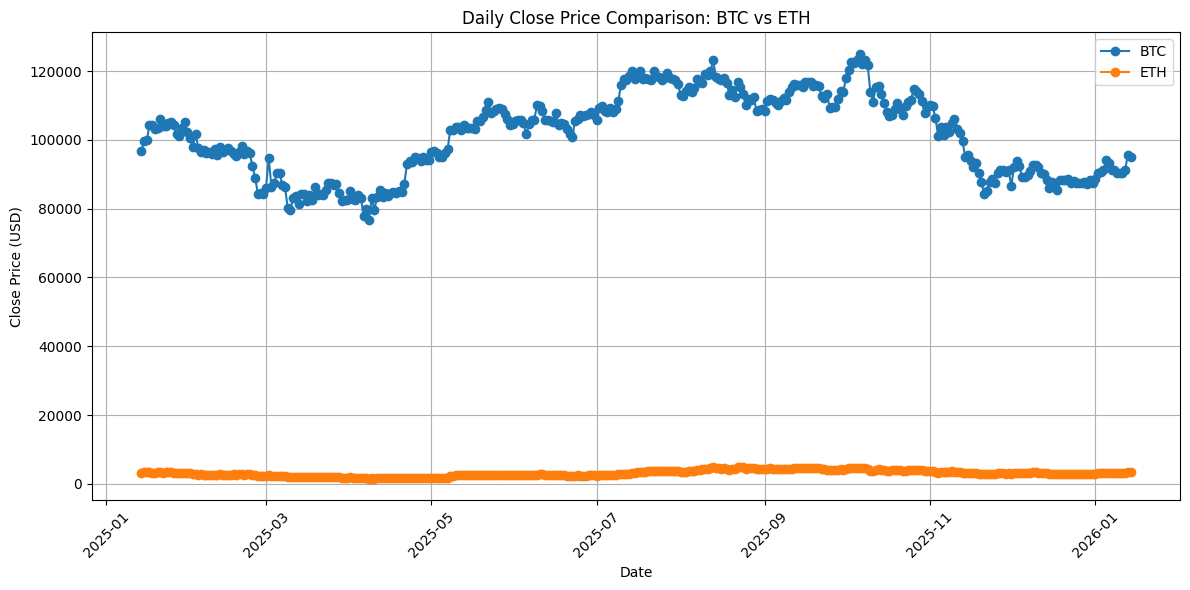

In [26]:
plt.figure(figsize=(12, 6))

for coin_id, df in coin_tables:
    if "date" in df.columns and "price_close_usd" in df.columns:
        plt.plot(df["date"], df["price_close_usd"], marker="o", label=coin_id)
    else:
        print(f"Skipping {coin_id}: 'date' or 'price_close_usd' column missing.")

plt.title("Daily Close Price Comparison: BTC vs ETH")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


**task 8.2 – Individual line charts per coin (daily close price)**

**Goal:** Create **two separate figures**, one for BTC and one for ETH.

**Requirements (for each coin):**
- Use `date` on x-axis and `price_close_usd` on y-axis.
- Title example:
  - `BTC Daily Closing Price`
  - `ETH Daily Closing Price`
- Labels:
  - x: `Date`
  - y: `Closing Price (USD)`
- Each coin must be plotted in its **own figure** (not subplots).

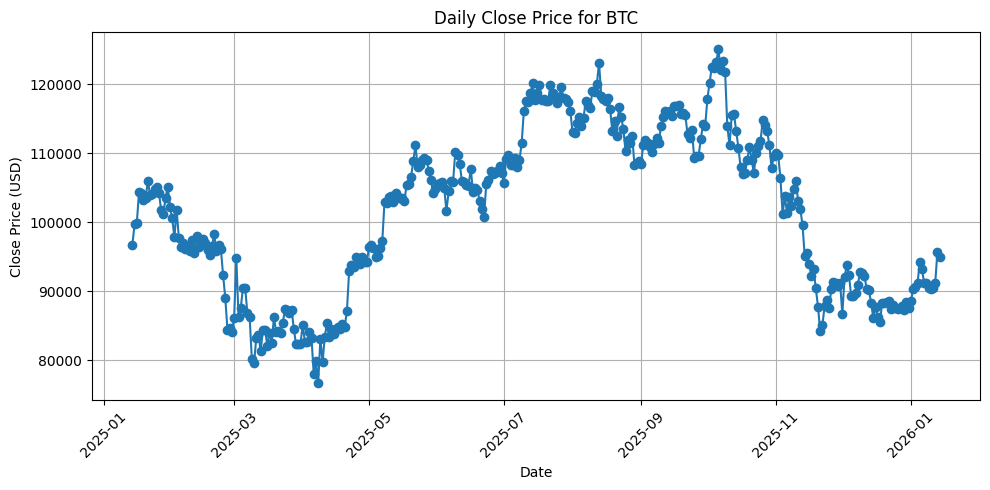

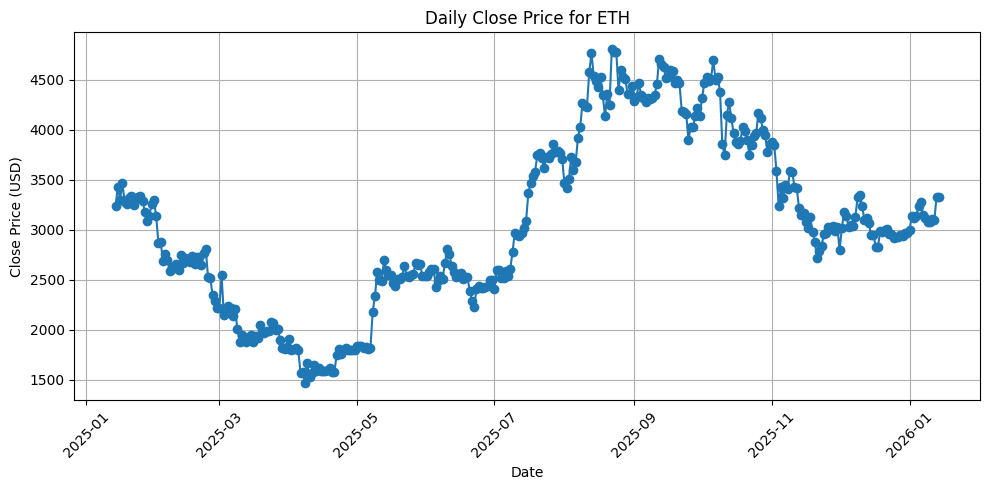

In [27]:
for coin_id, df in coin_tables:
    if "date" not in df.columns or "price_close_usd" not in df.columns:
        print(f"Skipping {coin_id}: 'date' or 'price_close_usd' column missing.")
        continue

    plt.figure(figsize=(10, 5))
    plt.plot(df["date"], df["price_close_usd"], marker="o")
    plt.title(f"Daily Close Price for {coin_id}")
    plt.xlabel("Date")
    plt.ylabel("Close Price (USD)")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


**task 8.3 – Bar charts of daily 24h trading volume per coin (For readability, we may only plot the first 30 days)**

*(For readability, we may only plot the first 30 days.)*

**Goal:** For each coin, create a bar chart for **the first 30 rows (days)**.

**Requirements (for each coin):**
- Filter the data to the **first 30 days after sorting by date**.
- Bar chart:
  - x-axis: `date` (first 30 days)
  - y-axis: `volume_24h_close_usd`
- Title example:
  - `BTC Daily Trading Volume (First 30 Days)`
  - `ETH Daily Trading Volume (First 30 Days)`
- Labels:
  - x: `Date`
  - y: `24h Trading Volume (USD)`
- Make it readable:
  - Rotate date labels (almost always necessary for bar charts).
  - Use `tight_layout()`.

**Optional:**
- Display volume in **100 billions** by dividing by `1e11` and updating the y-axis label.


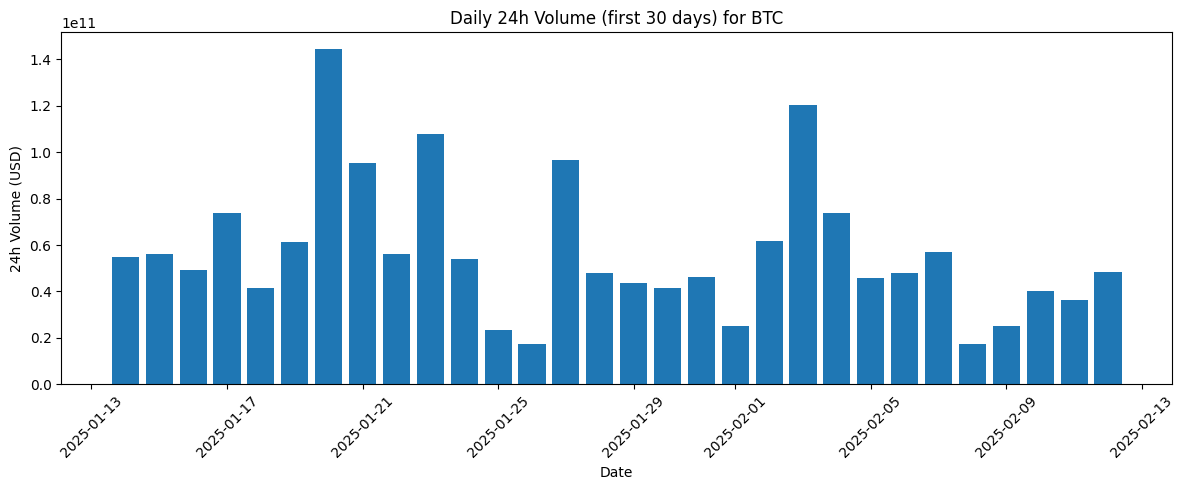

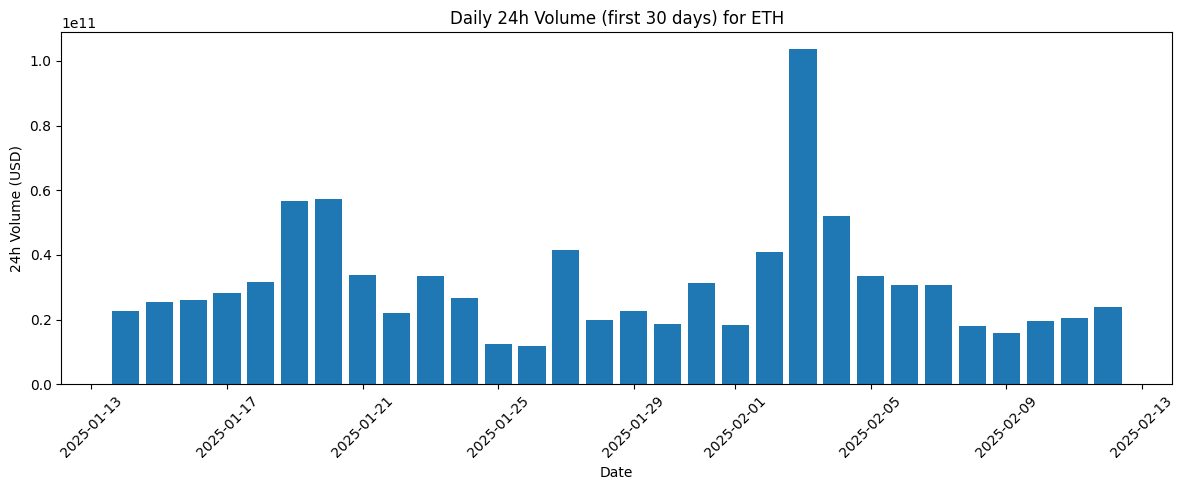

In [28]:
for coin_id, df in coin_tables:
    if "date" not in df.columns or "volume_24h_close_usd" not in df.columns:
        print(f"Skipping {coin_id}: 'date' or 'volume_24h_close_usd' column missing.")
        continue

    # For readability, we may only plot the first 30 days
    df_subset = df.head(30)

    plt.figure(figsize=(12, 5))
    plt.bar(df_subset["date"], df_subset["volume_24h_close_usd"])
    plt.title(f"Daily 24h Volume (first 30 days) for {coin_id}")
    plt.xlabel("Date")
    plt.ylabel("24h Volume (USD)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


**task 8.4 – Pie chart of average market cap share for BTC vs ETH**

**Goal:** A pie chart comparing **average** market cap share.

**Requirements:**
- Compute:
  - `btc_avg = mean(btc['market_cap_close_usd'])`
  - `eth_avg = mean(eth['market_cap_close_usd'])`
- Pie chart should have **two slices**: BTC and ETH.
- Labels: `BTC`, `ETH`
- Title example: `Average Market Cap Share (BTC vs ETH)`
- Show **percentages** on the chart (e.g., `autopct="%.1f%%"`).

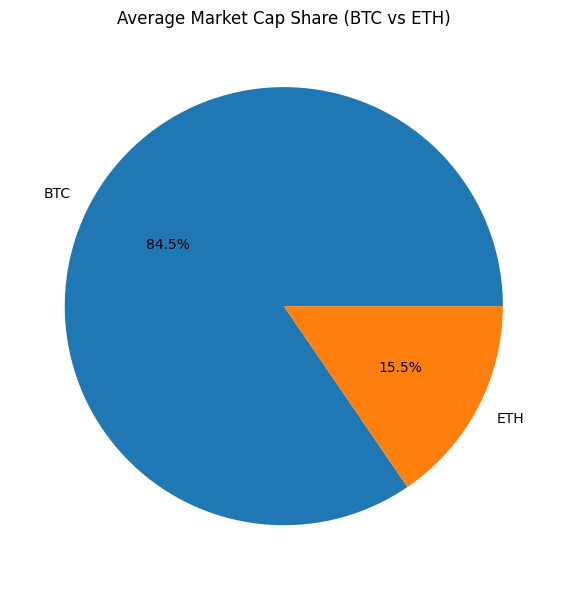

In [29]:
avg_caps = {}

for coin_id, df in coin_tables:
    if "market_cap_close_usd" in df.columns:
        avg_caps[coin_id] = df["market_cap_close_usd"].mean()

if avg_caps:
    labels = list(avg_caps.keys())
    sizes = list(avg_caps.values())

    plt.figure(figsize=(6, 6))
    plt.pie(sizes, labels=labels, autopct="%1.1f%%")
    plt.title("Average Market Cap Share (BTC vs ETH)")
    plt.tight_layout()
    plt.show()
else:
    print("No suitable 'market_cap_close_usd' columns found for pie chart.")


**task 8.5 – Scatter plots of daily close price vs 24h volume per coin**

**Goal:** For each coin, show the relationship between price and trading volume.

**Requirements (for each coin):**
- Scatter plot:
  - x-axis: `price_close_usd`
  - y-axis: `volume_24h_close_usd`
- Title example:
  - `BTC: Price vs Trading Volume`
  - `ETH: Price vs Trading Volume`
- Labels:
  - x: `Closing Price (USD)`
  - y: `24h Trading Volume (USD)`

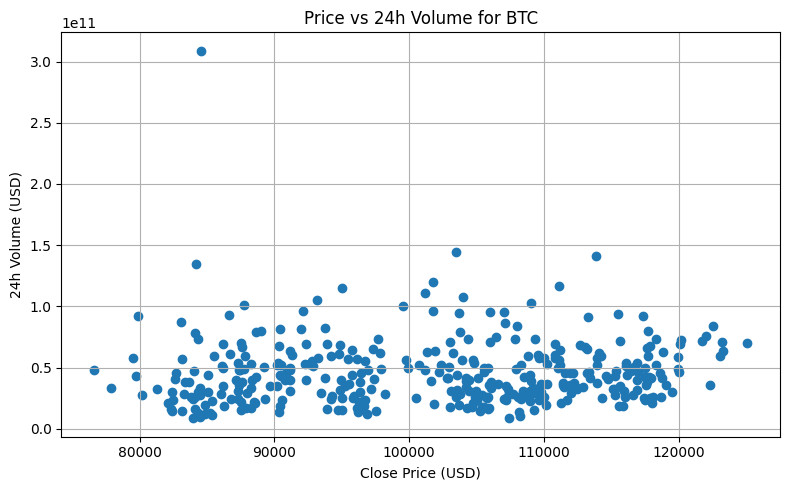

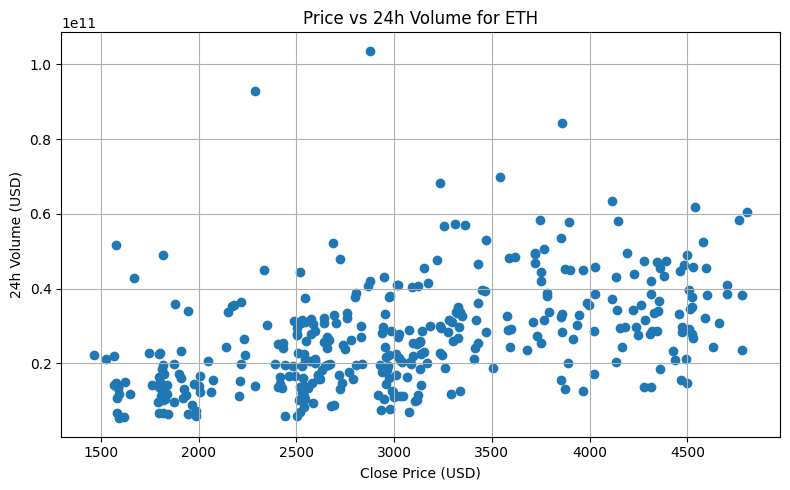

In [30]:
for coin_id, df in coin_tables:
    if "price_close_usd" not in df.columns or "volume_24h_close_usd" not in df.columns:
        print(f"Skipping {coin_id}: 'price_close_usd' or 'volume_24h_close_usd' column missing.")
        continue

    plt.figure(figsize=(8, 5))
    plt.scatter(df["price_close_usd"], df["volume_24h_close_usd"])
    plt.title(f"Price vs 24h Volume for {coin_id}")
    plt.xlabel("Close Price (USD)")
    plt.ylabel("24h Volume (USD)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
